# 03 — El modelo

Tres experimentos con el mismo modelo: **A** solo Fpz-Cz, **B** solo Pz-Oz, **C** los dos.
Hiperparámetros por validación cruzada sobre los 62 sujetos de desarrollo; el test de 16
se mira una vez, al final.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.axisbelow": True, "font.size": 9})
TINTA, GRIS = "#3a3a3a", "#8a8a8a"
SEMILLA = 42

ESPECTRALES = (["potencia_total_log"]
               + [f"abs_{b}" for b in ("delta", "theta", "alpha", "sigma", "beta")]
               + [f"rel_{b}" for b in ("delta", "theta", "alpha", "sigma", "beta")]
               + ["sef95"])
ARQUITECTURA = ["horas_dormidas", "eficiencia", "minutos_despierto", "minutos_hasta_rem",
                "pct_sueno_en_N1", "pct_sueno_en_N2", "pct_sueno_en_N3", "pct_sueno_en_REM"]

## 0 · MLflow

Las corridas van al servidor del EC2. `conectar()` lee la IP de `../config.yaml` y
comprueba `/health` antes de nada: si el servidor no responde, falla aquí. Sin esa
comprobación MLflow no da error — escribe en un `mlruns/` local y la UI aparece vacía.

**Un solo experimento con los tres canales dentro.** Cada canal es una corrida padre y
de ella cuelgan las 91 combinaciones de su rejilla. MLflow compara dentro de un
experimento, no entre experimentos, y comparar A contra B contra C es justo el objetivo
del notebook.

In [2]:
import sys
sys.path.append("..")

import mlflow, mlflow.sklearn
from config import conectar

conectar()                                  # falla de inmediato si el EC2 no responde
mlflow.set_experiment("edad-cerebral-sebastian")

print(f"registrando en {mlflow.get_tracking_uri()}")

registrando en http://18.207.240.152:8050


## 1 · Los datos

Se promedian las dos noches de cada sujeto. La arquitectura del sueño no se duplica: sale
del hipnograma, que es el mismo para los dos canales.

| Experimento | Espectro | Arquitectura | Total |
|---|---:|---:|---:|
| **A** · solo Fpz-Cz | 12 | 8 | 20 |
| **B** · solo Pz-Oz | 12 | 8 | 20 |
| **C** · los dos | 24 | 8 | 32 |

In [3]:
def por_sujeto(ruta):
    n = pd.read_csv(ruta)
    cols = [c for c in n.columns if c not in ("subject", "night", "registro", "sex", "age")]
    return (n.groupby("subject").agg({**{c: "mean" for c in cols}, "age": "first"})
            .rename(columns={"age": "edad"}))

fpz = por_sujeto("datos/caracteristicas_noche_FpzCz.csv")
pz  = por_sujeto("datos/caracteristicas_noche_PzOz.csv")
assert (fpz.index == pz.index).all() and np.allclose(fpz.edad, pz.edad)

espec_fpz = fpz[[f"mix_{f}" for f in ESPECTRALES]].add_suffix("_FpzCz")
espec_pz  = pz[[f"mix_{f}" for f in ESPECTRALES]].add_suffix("_PzOz")
datos = pd.concat([espec_fpz, espec_pz, fpz[ARQUITECTURA], fpz[["edad"]]], axis=1)

EXPERIMENTOS = {
    "A · Fpz-Cz":  list(espec_fpz.columns) + ARQUITECTURA,
    "B · Pz-Oz":   list(espec_pz.columns) + ARQUITECTURA,
    "C · los dos": list(espec_fpz.columns) + list(espec_pz.columns) + ARQUITECTURA,
}
print(f"{len(datos)} sujetos · edad {datos.edad.min():.0f}-{datos.edad.max():.0f}")
for n, c in EXPERIMENTOS.items():
    print(f"  {n:14s} {len(c):2d} columnas")

78 sujetos · edad 25-101
  A · Fpz-Cz     20 columnas
  B · Pz-Oz      20 columnas
  C · los dos    32 columnas


## 2 · La partición

La fija del proyecto: 62 de desarrollo, 16 de test, 5 folds. Cada fila es una persona.

In [4]:
split = json.loads(Path("../subject_split_seed42.json").read_text())
TV, TEST = split["train_validation_subject_ids"], split["test_subject_ids"]
y_tv, y_test = datos.loc[TV, "edad"].values, datos.loc[TEST, "edad"].values
pos = {s: i for i, s in enumerate(TV)}

print(f"desarrollo {len(TV)} · test {len(TEST)} (intacto) · {len(split['cv_folds'])} folds")

desarrollo 62 · test 16 (intacto) · 5 folds


## 3 · El modelo

Ridge con un término extra, de peso `λ`, que penaliza que el BAI dependa de la edad. Sin
él el modelo tira hacia la media y el BAI acaba midiendo la edad en vez del cerebro.

In [5]:
class RidgeBAI(BaseEstimator, RegressorMixin):
    # min (1/n)||Xw - y||^2 + (alpha/n)||w||^2 + lam*cov(BAI, y)^2
    #
    # El alpha se divide por n para que la rejilla signifique lo mismo que en
    # sklearn.Ridge. Con lam=0 reproduce Ridge exactamente.

    def __init__(self, alpha=1.0, lam=0.0):
        self.alpha, self.lam = alpha, lam

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float)
        n, p = X.shape
        self.media_X_, self.media_y_ = X.mean(0), y.mean()
        Xc, c = X - self.media_X_, y - self.media_y_
        a = Xc.T @ c / n
        b = c @ c / n
        A = Xc.T @ Xc / n + (self.alpha / n) * np.eye(p) + self.lam * np.outer(a, a)
        self.coef_ = np.linalg.solve(A, (1 + self.lam * b) * a)
        self.intercept_ = self.media_y_ - self.media_X_ @ self.coef_
        return self

    def predict(self, X):
        return np.asarray(X, float) @ self.coef_ + self.intercept_


def pipeline(alpha, lam):
    """Imputar y escalar van dentro: se ajustan solo con el train de cada fold."""
    return Pipeline([("imputar", SimpleImputer(strategy="median")),
                     ("escalar", StandardScaler()),
                     ("ridge", RidgeBAI(alpha=alpha, lam=lam))])


def cv(X, alpha, lam):
    """Devuelve el error de train promediado sobre los folds y las predicciones
    out-of-fold: cada sujeto predicho por un modelo que no lo vio."""
    p, err_train = np.full(len(TV), np.nan), []
    for f in split["cv_folds"]:
        itr = [pos[s] for s in f["train_subject_ids"]]
        iva = [pos[s] for s in f["val_subject_ids"]]
        m = pipeline(alpha, lam).fit(X[itr], y_tv[itr])
        err_train.append(np.mean(np.abs(m.predict(X[itr]) - y_tv[itr])))
        p[iva] = m.predict(X[iva])
    return np.mean(err_train), p

### Comprobación

Con `λ = 0` tiene que reproducir `Ridge` exactamente.

In [6]:
X = datos.loc[TV, EXPERIMENTOS["C · los dos"]].values
_, p0 = cv(X, 10.0, 0.0)

ref = np.full(len(TV), np.nan)
for f in split["cv_folds"]:
    itr = [pos[s] for s in f["train_subject_ids"]]
    iva = [pos[s] for s in f["val_subject_ids"]]
    ref[iva] = Pipeline([("i", SimpleImputer(strategy="median")), ("e", StandardScaler()),
                         ("r", Ridge(alpha=10.0))]).fit(X[itr], y_tv[itr]).predict(X[iva])

print(f"lambda=0 reproduce Ridge: max|dif| = {np.abs(p0 - ref).max():.1e}")
assert np.abs(p0 - ref).max() < 1e-9

lambda=0 reproduce Ridge: max|dif| = 4.3e-14


## 4 · Búsqueda de hiperparámetros

91 combinaciones de `α` × `λ`. Se elige la de menor error de validación entre las que
baten a predecir la media y dejan `|r(BAI, edad)| < 0,25`.

In [7]:
ALPHAS = np.logspace(-2, 4, 13)
LAMBDAS = [0, 0.003, 0.01, 0.03, 0.1, 0.3, 1]
OBJETIVO_SESGO = 0.25
TRIVIAL_CV = np.mean(np.abs(y_tv - y_tv.mean()))


def buscar(cols):
    X = datos.loc[TV, cols].values
    filas = []
    for al in ALPHAS:
        for lam in LAMBDAS:
            err_train, p = cv(X, al, lam)
            filas.append({"alpha": al, "lambda": lam, "train": err_train,
                          "CV MAE": np.mean(np.abs(p - y_tv)),
                          "r(BAI,edad)": stats.pearsonr(y_tv, p - y_tv)[0]})
    r = pd.DataFrame(filas)
    utiles = r[r["CV MAE"] < TRIVIAL_CV]
    limpios = utiles[utiles["r(BAI,edad)"].abs() < OBJETIVO_SESGO]
    if len(limpios):
        return r, limpios.loc[limpios["CV MAE"].idxmin()], "cumple"
    if len(utiles):
        return r, utiles.loc[utiles["CV MAE"].idxmin()], "sesgo no alcanzado"
    return r, r.loc[r["CV MAE"].idxmin()], "no bate la media"


busquedas = {n: buscar(c) for n, c in EXPERIMENTOS.items()}

for n, (r, m, estado) in busquedas.items():
    print(f"{n:14s} alpha = {m['alpha']:7.2f}   lambda = {m['lambda']:<6g}"
          f"   CV MAE = {m['CV MAE']:5.2f}   r(BAI,edad) = {m['r(BAI,edad)']:+.3f}   [{estado}]")

A · Fpz-Cz     alpha =   10.00   lambda = 0.01     CV MAE = 10.36   r(BAI,edad) = -0.248   [cumple]
B · Pz-Oz      alpha =    0.32   lambda = 0.003    CV MAE = 11.62   r(BAI,edad) = -0.201   [cumple]
C · los dos    alpha =    3.16   lambda = 0.01     CV MAE = 10.43   r(BAI,edad) = -0.226   [cumple]


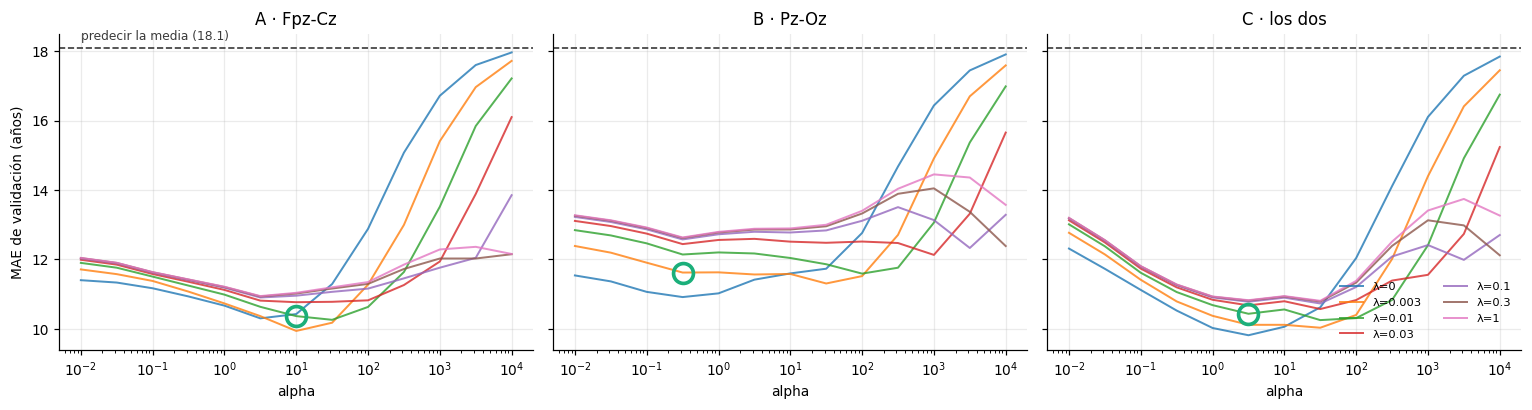

In [8]:
fig_rejilla, ejes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (n, (r, m, _)) in zip(ejes, busquedas.items()):
    for lam in LAMBDAS:
        s = r[r["lambda"] == lam]
        ax.semilogx(s.alpha, s["CV MAE"], "-", lw=1.3, alpha=.8, label=f"λ={lam:g}")
    ax.plot(m.alpha, m["CV MAE"], "o", ms=13, mfc="none", mec="#1baf7a", mew=2.4)
    ax.axhline(TRIVIAL_CV, ls="--", color=TINTA, lw=1.1)
    ax.set(xlabel="alpha", title=n)
ejes[0].set_ylabel("MAE de validación (años)")
ejes[0].annotate(f"predecir la media ({TRIVIAL_CV:.1f})", xy=(1e-2, TRIVIAL_CV + .25),
                 fontsize=8, color=TINTA)
ejes[2].legend(frameon=False, fontsize=7.5, ncol=2, loc="lower right")
plt.tight_layout(); plt.show()

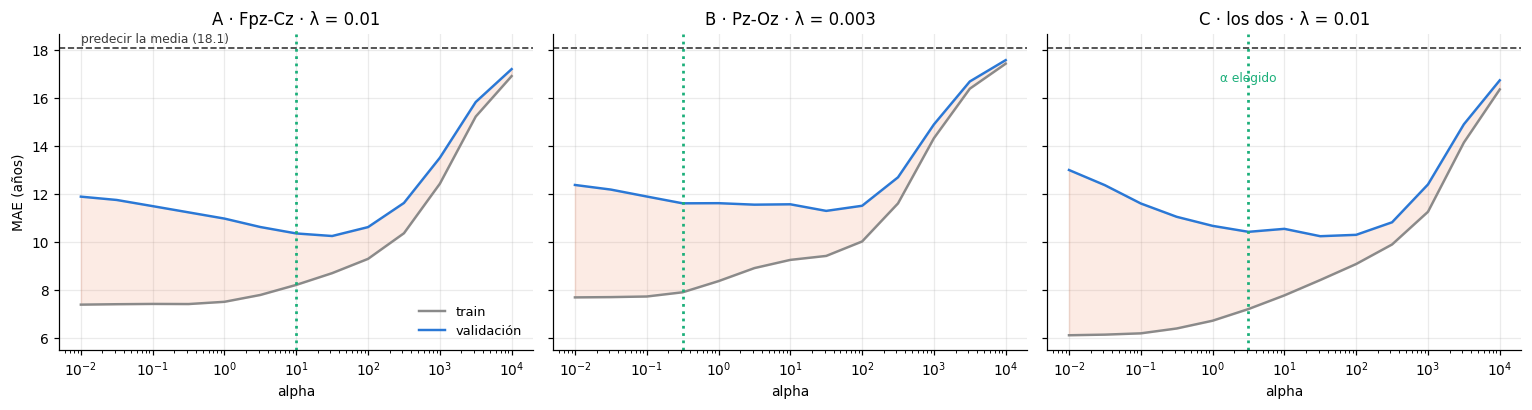

In [9]:
fig_sesgo, ejes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (n, (r, m, _)) in zip(ejes, busquedas.items()):
    s = r[r["lambda"] == m["lambda"]].sort_values("alpha")
    ax.fill_between(s.alpha, s["train"], s["CV MAE"], color="#eb6834", alpha=.13)
    ax.semilogx(s.alpha, s["train"], "-", lw=1.6, color=GRIS, label="train")
    ax.semilogx(s.alpha, s["CV MAE"], "-", lw=1.6, color="#2a78d6", label="validación")
    ax.axvline(m["alpha"], ls=":", color="#1baf7a", lw=1.8)
    ax.axhline(TRIVIAL_CV, ls="--", color=TINTA, lw=1.1)
    ax.set(xlabel="alpha", title=f"{n} · λ = {m['lambda']:g}")
ejes[0].set_ylabel("MAE (años)")
ejes[0].legend(frameon=False, fontsize=8.5, loc="lower right")
ejes[0].annotate(f"predecir la media ({TRIVIAL_CV:.1f})", xy=(1e-2, TRIVIAL_CV + .25),
                 fontsize=8, color=TINTA)
ejes[2].annotate("α elegido", xy=(busquedas["C · los dos"][1]["alpha"], TRIVIAL_CV - 1.4),
                 fontsize=8, color="#1baf7a", ha="center")
plt.tight_layout(); plt.show()

## 5 · El test

Cada mejor modelo, reentrenado con los 62 y evaluado una vez sobre los 16.

In [10]:
filas, predicciones, modelos = [], {}, {}
for n, cols in EXPERIMENTOS.items():
    Xtv, Xte = datos.loc[TV, cols].values, datos.loc[TEST, cols].values
    _, m, _ = busquedas[n]
    modelo = pipeline(m["alpha"], m["lambda"]).fit(Xtv, y_tv)
    p_te = modelo.predict(Xte)
    predicciones[n] = p_te
    modelos[n] = modelo
    filas.append({
        "experimento": n, "columnas": len(cols),
        "train": np.mean(np.abs(modelo.predict(Xtv) - y_tv)),
        "validación": m["CV MAE"],
        "test": np.mean(np.abs(p_te - y_test)),
        "r(BAI,edad)": stats.pearsonr(y_test, p_te - y_test)[0],
    })

tabla = pd.DataFrame(filas).round(2)
trivial = np.mean(np.abs(y_test - y_tv.mean()))

print("MAE en años · el mejor modelo de cada experimento\n")
print(tabla.to_string(index=False))
print(f"\npredecir siempre la edad media -> {trivial:.2f}"
      f"   ·   r(BAI, edad) ideal = 0, objetivo < {OBJETIVO_SESGO}")

MAE en años · el mejor modelo de cada experimento

experimento  columnas  train  validación  test  r(BAI,edad)
 A · Fpz-Cz        20   8.37       10.36 10.85        -0.46
  B · Pz-Oz        20   8.14       11.62 14.59        -0.29
C · los dos        32   7.48       10.43  9.15        -0.48

predecir siempre la edad media -> 19.10   ·   r(BAI, edad) ideal = 0, objetivo < 0.25


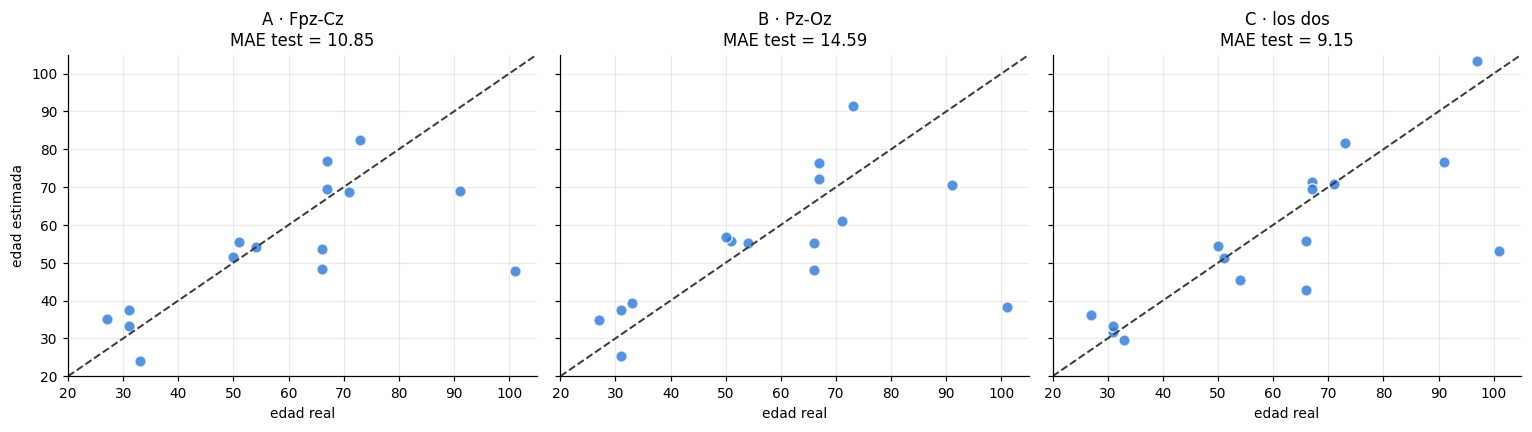

In [11]:
lim = [20, 105]
fig_test, ejes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for ax, (n, p) in zip(ejes, predicciones.items()):
    ax.scatter(y_test, p, s=55, alpha=.8, color="#2a78d6", edgecolor="white")
    ax.plot(lim, lim, "--", color=TINTA, lw=1.3)
    ax.set(xlim=lim, ylim=lim, xlabel="edad real",
           title=f"{n}\nMAE test = {np.mean(np.abs(p - y_test)):.2f}")
ejes[0].set_ylabel("edad estimada")
plt.tight_layout(); plt.show()

## 6 · Registro en MLflow

Una corrida padre por experimento con el modelo elegido y su cifra de test, y 91
corridas anidadas —una por combinación de la rejilla— con lo que se vio en validación.

Lo que queda registrado de cada padre:

| | |
|---|---|
| **Datos** | los dos CSV como *datasets* de MLflow: origen, esquema y perfil |
| **Parámetros** | `alpha`, `lambda`, nº de columnas, sujetos, folds, semilla, criterio |
| **Métricas** | MAE de train/validación/test, RMSE, MedAE, R², `r(BAI,edad)` y la referencia de predecir la media |
| **Artefactos** | las tres figuras, la rejilla completa, las columnas usadas y la partición |
| **Modelo** | el `Pipeline` con su firma; solo el ganador entra al Registry |

Las 273 corridas anidadas tardan un par de minutos: son peticiones HTTP contra el EC2.

In [12]:
import io
from contextlib import redirect_stdout

from mlflow.models import infer_signature

ETIQUETAS = {"A · Fpz-Cz": "A", "B · Pz-Oz": "B", "C · los dos": "C"}
GANADOR = "C · los dos"
FIGURAS = {"rejilla_cv.png": fig_rejilla,
           "train_vs_validacion.png": fig_sesgo,
           "test_real_vs_estimada.png": fig_test}

# De donde salen los datos. Se declara en las tres corridas: las dos tablas se leen
# siempre, y que columnas usa cada experimento queda en columnas.json.
ENTRADAS = [mlflow.data.from_pandas(pd.read_csv(ruta), source=ruta, targets="age",
                                    name=f"caracteristicas_{canal}")
            for canal, ruta in (("FpzCz", "datos/caracteristicas_noche_FpzCz.csv"),
                                ("PzOz",  "datos/caracteristicas_noche_PzOz.csv"))]


def registrar(nombre, cols):
    """Una corrida padre con la rejilla anidada. Devuelve el run_id."""
    r, mejor, estado = busquedas[nombre]
    modelo, p_te = modelos[nombre], predicciones[nombre]
    p_tv = modelo.predict(datos.loc[TV, cols].values)
    res_te = p_te - y_test

    with mlflow.start_run(run_name=nombre) as padre:
        mlflow.set_tags({"canal": ETIQUETAS[nombre], "modelo": "RidgeBAI",
                         "notebook": "03_modelo.ipynb", "seleccion": estado})
        for ds in ENTRADAS:
            mlflow.log_input(ds, context="training")

        mlflow.log_params({
            "alpha": mejor["alpha"], "lambda": mejor["lambda"],
            "n_columnas": len(cols), "n_sujetos_desarrollo": len(TV),
            "n_sujetos_test": len(TEST), "n_folds": len(split["cv_folds"]),
            "semilla": SEMILLA, "objetivo_sesgo": OBJETIVO_SESGO,
            "imputacion": "mediana", "escalado": "StandardScaler",
            "rejilla": f"{len(ALPHAS)} alphas x {len(LAMBDAS)} lambdas",
            "criterio": "menor CV MAE entre las que baten la media con |r(BAI,edad)| < objetivo",
        })

        mlflow.log_metrics({
            "mae_train": np.mean(np.abs(p_tv - y_tv)),
            "mae_cv": mejor["CV MAE"],
            "mae_test": np.mean(np.abs(res_te)),
            "rmse_test": np.sqrt(np.mean(res_te ** 2)),
            "medae_test": np.median(np.abs(res_te)),
            "r2_test": 1 - np.sum(res_te ** 2) / np.sum((y_test - y_test.mean()) ** 2),
            "r_pred_edad_test": stats.pearsonr(y_test, p_te)[0],
            "r_bai_edad_cv": mejor["r(BAI,edad)"],
            "r_bai_edad_test": stats.pearsonr(y_test, res_te)[0],
            "mae_baseline_media_cv": TRIVIAL_CV,
            "mae_baseline_media_test": trivial,
        })

        # La rejilla: una corrida anidada por combinacion. Es lo que alimenta el
        # Parallel Coordinates Plot de la UI.
        for _, f in r.iterrows():
            with mlflow.start_run(run_name=f"a={f.alpha:.3g} l={f['lambda']:g}", nested=True):
                # el canal tambien en la anidada: sin el, la UI solo las deja ver
                # expandiendo su padre, y no se pueden filtrar en plano
                mlflow.set_tags({"canal": ETIQUETAS[nombre], "tipo": "rejilla"})
                mlflow.log_params({"alpha": f["alpha"], "lambda": f["lambda"],
                                   "n_columnas": len(cols)})
                mlflow.log_metrics({"mae_train": f["train"], "mae_cv": f["CV MAE"],
                                    "r_bai_edad_cv": f["r(BAI,edad)"],
                                    "abs_r_bai_edad_cv": abs(f["r(BAI,edad)"]),
                                    "bate_la_media": float(f["CV MAE"] < TRIVIAL_CV)})

        mlflow.log_table(r, "rejilla.json")
        mlflow.log_dict({"columnas": cols}, "columnas.json")
        mlflow.log_artifact("../subject_split_seed42.json")
        for archivo, figura in FIGURAS.items():
            mlflow.log_figure(figura, archivo)

        # cloudpickle y no el skops por defecto: RidgeBAI se define en el notebook y
        # cloudpickle la serializa POR VALOR, asi el modelo carga donde la clase no existe.
        mlflow.sklearn.log_model(
            modelo, name="modelo", serialization_format="cloudpickle",
            signature=infer_signature(datos.loc[TV, cols].values, p_te),
            registered_model_name="edad-cerebral" if nombre == GANADOR else None)

        return padre.info.run_id


# MLflow 3 escribe un enlace por corrida directo a stdout, sin forma de apagarlo.
# Con 273 anidadas eso hornearia la IP del EC2 —que cambia en cada arranque—
# cientos de veces dentro del .ipynb que va al repositorio.
for nombre, cols in EXPERIMENTOS.items():
    with redirect_stdout(io.StringIO()):
        run_id = registrar(nombre, cols)
    print(f"{nombre:14s} -> {run_id}")

print(f"\n{mlflow.get_tracking_uri()}  ·  experimento 'edad-cerebral-sebastian'")

/opt/anaconda3/envs/master/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
/opt/anaconda3/envs/master/lib/python3.11/site-packages/mlflow/data/dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


/opt/anaconda3/envs/master/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


2026/08/30 00:51:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


A · Fpz-Cz     -> 6d4e7c081b80482c8a4d321aefb687bc


2026/08/30 00:53:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/08/30 00:55:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Successfully registered model 'edad-cerebral'.


2026/08/30 00:55:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: edad-cerebral, version 1


Created version '1' of model 'edad-cerebral'.


C · los dos    -> bdeed1445fe94a5db6ad906ec99125db

http://18.207.240.152:8050  ·  experimento 'edad-cerebral-sebastian'


## Conclusión

Gana juntar los dos canales: **9,15** años de MAE en test, contra 19,10 de predecir
siempre la edad media. Fpz-Cz solo da 10,85 y Pz-Oz solo 14,59.

Los tres cumplen el objetivo de sesgo en validación cruzada pero ninguno en test, donde
`r(BAI, edad)` se queda en −0,48.